
# Bitcoin Price & News Analysis Tutorial

This notebook demonstrates how to build a live Bitcoin monitoring and analysis system using OpenSearch and semantic search. We use `bitcoin_utils.py` for reusable functions.

### What this covers:
- Live Bitcoin price fetching (CoinGecko)
- News scraping (CryptoPanic API)
- Ingestion into OpenSearch
- Semantic embedding (Sentence Transformers)
- Anomaly detection & correlation
- Visualizations


In [3]:
# Imports
from bitcoin_utils import *

### Phase 1: Live Bitcoin Price Fetch
This will append live price points every 45 seconds to `data/bitcoin_prices.json`. Press **stop** to interrupt manually.

In [4]:
# Optional: Only use this if running the fetcher live
# Commented to avoid infinite loop in notebook
#fetch_live_bitcoin_price()

### Phase 2: Ingest Price Data into OpenSearch
This reads `bitcoin_prices.json`, calculates % change, and inserts new records.


In [5]:
# Ingest historical price data to OpenSearch
ingest_prices_to_opensearch()

Ingested 34 new records into `bitcoin-prices`.


### Phase 3: Crypto News Scraping
Fetches the latest news related to Bitcoin using CryptoPanic API and saves it into `data/crypto_news.json`.


In [6]:
# Optional: Uncomment to run live scraping
# scrape_crypto_news()

### Phase 4: Semantic Embedding & Ingestion
This encodes news titles as dense vectors and stores them in a new OpenSearch index: `crypto-news-semantic`

In [7]:
# Semantic Embedding & Indexing of News
embed_and_ingest_semantic_news()


Embedding 700 articles...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Successfully indexed 700 semantic news articles into `crypto-news-semantic`.


### Phase 5: Visualization of Anomalies
Plot Bitcoin price over time and mark anomaly points (±2% change)

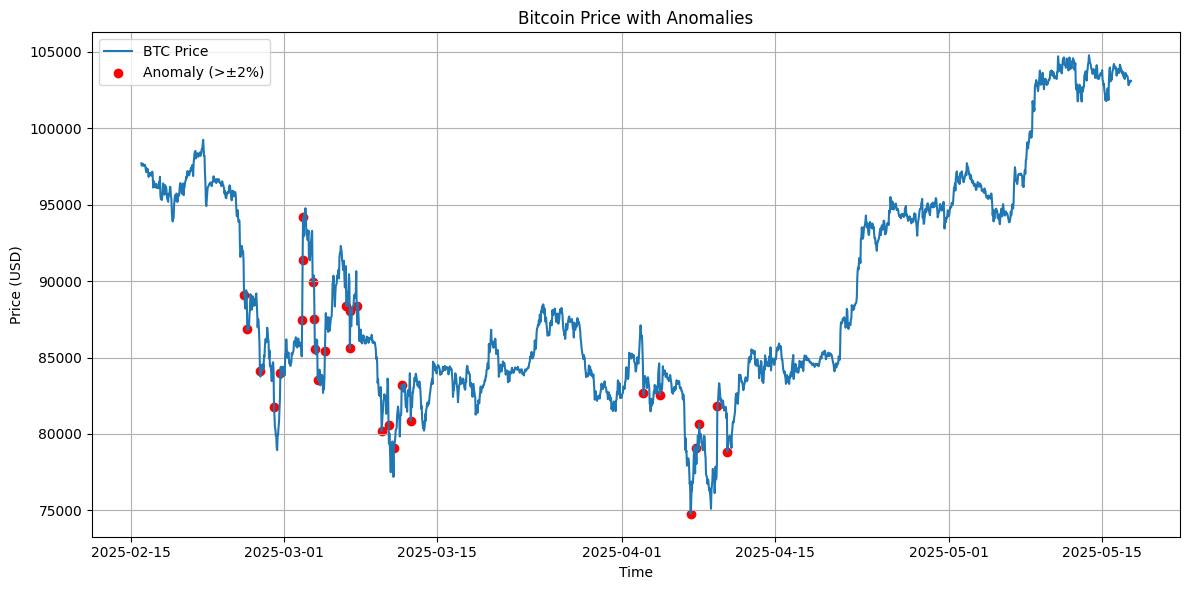

In [8]:
import matplotlib.pyplot as plt

# Load & prepare data
df = pd.read_json(BITCOIN_FILE, lines=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['pct_change'] = df['price'].pct_change() * 100
anomalies = df[abs(df['pct_change']) > 2]

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['price'], label='BTC Price')
plt.scatter(anomalies['timestamp'], anomalies['price'], color='red', label='Anomaly (>±2%)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.title('Bitcoin Price with Anomalies')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Summary
You now have a complete pipeline that:
- Collects live price and news data
- Stores and analyzes it using OpenSearch
- Applies semantic search to news
- Detects anomalies and correlates them with news

> You can now build dashboards in Kibana/OpenSearch Dashboards


In [9]:
#Query OpenSearch manually (example)
from opensearchpy import OpenSearch

client = OpenSearch([{"host": "localhost", "port": 9200}], use_ssl=False)

# Example BM25 search
query = {
    "query": {
        "match": {
            "title": "bitcoin regulation"
        }
    }
}
response = client.search(index="crypto-news", body=query)
print("BM25 Search Results:")
for hit in response['hits']['hits'][:5]:
    print(f"- {hit['_source']['title']}")

BM25 Search Results:
- Bitcoin News: Nasdaq-Listed Basel Medical Group Unveils $1 Billion Bitcoin Treasury Strategy
- Bitcoin News: Nasdaq-Listed Basel Medical Group Unveils $1 Billion Bitcoin Treasury Strategy
- Bitcoin News: Nasdaq-Listed Basel Medical Group Unveils $1 Billion Bitcoin Treasury Strategy
- Bitcoin News: Nasdaq-Listed Basel Medical Group Unveils $1 Billion Bitcoin Treasury Strategy
- Bitcoin News: Nasdaq-Listed Basel Medical Group Unveils $1 Billion Bitcoin Treasury Strategy


In [10]:
# Example semantic vector search
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

embedding = model.encode(["bitcoin regulation news"])[0].tolist()
sem_query = {
    "size": 3,
    "query": {
        "script_score": {
            "query": {"match_all": {}},
            "script": {
                "source": "cosineSimilarity(params.query_vector, 'embedding') + 1.0",
                "params": {"query_vector": embedding}
            }
        }
    }
}
sem_res = client.search(index="crypto-news-semantic", body=sem_query)
print("\nSemantic Search Results:")
for hit in sem_res['hits']['hits']:
    print(f"- {hit['_source']['title']}")



Semantic Search Results:
- From oil to Bitcoin: Saudi Central Bank stakes big on MicroStrategy
- Crypto Daybook Americas: Fintechs, Funds ‘Hoarding Bitcoin’ Even as Bulls Pause for Breath
- Bitcoin Surges as Institutional Interest Grows Amid Economic Uncertainty
